In [1]:
# ============================================
# STEP 1: Import Required Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Display plots inside notebook
%matplotlib inline

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# ============================================
# STEP 2: Load the Dataset
# ============================================

df = pd.read_csv("/content/Heart Disease UCI.xlsx.csv")

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.head()

Dataset loaded successfully!
Rows: 920
Columns: 16


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
# ============================================
# STEP 3: Dataset Information
# ============================================

print("="*60)
print("Dataset Information")
print("="*60)

print("\nShape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information

Shape of Dataset:
(920, 16)

Column Names:
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Data Types:
id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

Missing Values:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [4]:
# ============================================
# STEP 4: Statistical Summary
# ============================================

df.describe(include='all')

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
count,920.000000,920.000000,920,920,920,861.000000,890.000000,830,918,865.000000,865,858.000000,611,309.000000,434,920.000000
unique,NaN,NaN,2,4,4,NaN,NaN,2,3,NaN,2,NaN,3,NaN,3,NaN
top,NaN,NaN,Male,Cleveland,asymptomatic,NaN,NaN,False,normal,NaN,False,NaN,flat,NaN,normal,NaN
freq,NaN,NaN,726,304,496,NaN,NaN,692,551,NaN,528,NaN,345,NaN,196,NaN
mean,460.500000,53.510870,NaN,NaN,NaN,132.132404,199.130337,NaN,NaN,137.545665,NaN,0.878788,NaN,0.676375,NaN,0.995652
std,265.725422,9.424685,NaN,NaN,NaN,19.066070,110.780810,NaN,NaN,25.926276,NaN,1.091226,NaN,0.935653,NaN,1.142693
min,1.000000,28.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,60.000000,NaN,-2.600000,NaN,0.000000,NaN,0.000000
25%,230.750000,47.000000,NaN,NaN,NaN,120.000000,175.000000,NaN,NaN,120.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000
50%,460.500000,54.000000,NaN,NaN,NaN,130.000000,223.000000,NaN,NaN,140.000000,NaN,0.500000,NaN,0.000000,NaN,1.000000
75%,690.250000,60.000000,NaN,NaN,NaN,140.000000,268.000000,NaN,NaN,157.000000,NaN,1.500000,NaN,1.000000,NaN,2.000000


In [5]:
# ============================================
# STEP 5: Data Preprocessing
# ============================================

# Remove the ID column (not useful for prediction)
df = df.drop(columns=["id"])

# Fill numerical missing values with the median
numerical_cols = ["trestbps", "chol", "thalch", "oldpeak", "ca"]

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with the most frequent value (mode)
categorical_cols = ["fbs", "restecg", "exang", "slope", "thal"]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after preprocessing:")
print(df.isnull().sum())

Missing values after preprocessing:
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


/tmp/ipykernel_1762/4241341154.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [6]:
# ============================================
# STEP 6: Encode Categorical Variables
# ============================================

# Convert categorical variables into numerical values
df_encoded = pd.get_dummies(df, drop_first=True)

print("="*60)
print("Encoded Dataset")
print("="*60)

print("Shape:", df_encoded.shape)

df_encoded.head()

Encoded Dataset
Shape: (920, 22)


,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,num,sex_Male,...,dataset_VA Long Beach,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,True,150.0,False,2.3,0.0,0,True,...,False,False,False,True,False,False,False,False,False,False
1,67,160.0,286.0,False,108.0,True,1.5,3.0,2,True,...,False,False,False,False,False,False,True,False,True,False
2,67,120.0,229.0,False,129.0,True,2.6,2.0,1,True,...,False,False,False,False,False,False,True,False,False,True
3,37,130.0,250.0,False,187.0,False,3.5,0.0,0,True,...,False,False,True,False,True,False,False,False,True,False
4,41,130.0,204.0,False,172.0,False,1.4,0.0,0,False,...,False,True,False,False,False,False,False,True,True,False


In [7]:
# ============================================
# STEP 7: Prepare Features and Target
# ============================================

# Convert target into binary classification
df_encoded["num"] = df_encoded["num"].apply(lambda x: 0 if x == 0 else 1)

# Features
X = df_encoded.drop("num", axis=1)

# Target
y = df_encoded["num"]

print("="*60)
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nTarget Distribution:")
print(y.value_counts())

Features Shape: (920, 21)
Target Shape: (920,)

Target Distribution:
num
1    509
0    411
Name: count, dtype: int64


In [8]:
# ============================================
# STEP 8: Train-Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("="*60)
print("TRAIN-TEST SPLIT")
print("="*60)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

TRAIN-TEST SPLIT
Training Features: (736, 21)
Testing Features : (184, 21)
Training Labels : (736,)
Testing Labels  : (184,)


In [9]:
# ============================================
# STEP 9: Train Random Forest Model
# ============================================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("="*60)
print("MODEL TRAINING")
print("="*60)

print("Random Forest model trained successfully!")

MODEL TRAINING
Random Forest model trained successfully!


In [10]:
# ============================================
# STEP 10: Model Evaluation
# ============================================

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("="*60)
print("MODEL PERFORMANCE")
print("="*60)

print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC Score:")
print(f"{roc_auc_score(y_test, y_pred):.4f}")

MODEL PERFORMANCE
Accuracy: 0.8424

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.78      0.82        82
           1       0.83      0.89      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184


Confusion Matrix:
[[64 18]
 [11 91]]

ROC-AUC Score:
0.8363


TOP 10 MOST IMPORTANT FEATURES
               Feature  Importance
2                 chol    0.133872
4               thalch    0.126565
0                  age    0.114530
6              oldpeak    0.103301
5                exang    0.084502
1             trestbps    0.071853
12  cp_atypical angina    0.062668
8             sex_Male    0.041049
19         thal_normal    0.032349
13      cp_non-anginal    0.030534


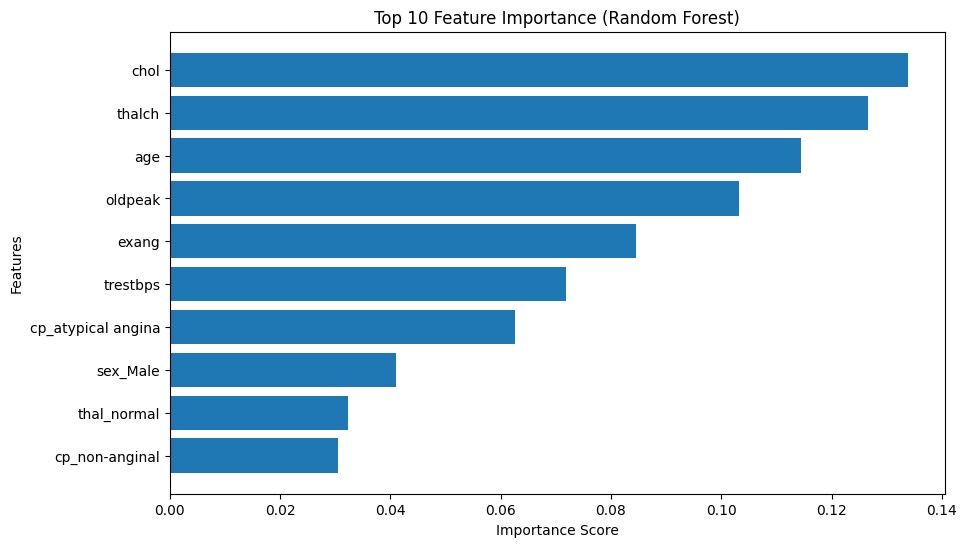

In [11]:
# ============================================
# STEP 11: Feature Importance
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

# Sort features
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("="*60)
print("TOP 10 MOST IMPORTANT FEATURES")
print("="*60)

print(feature_importance.head(10))

# Plot
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [12]:
# ============================================
# STEP 12: Install SHAP
# ============================================

!pip install shap -q

print("SHAP installed successfully!")

SHAP installed successfully!


SHAP SUMMARY PLOT


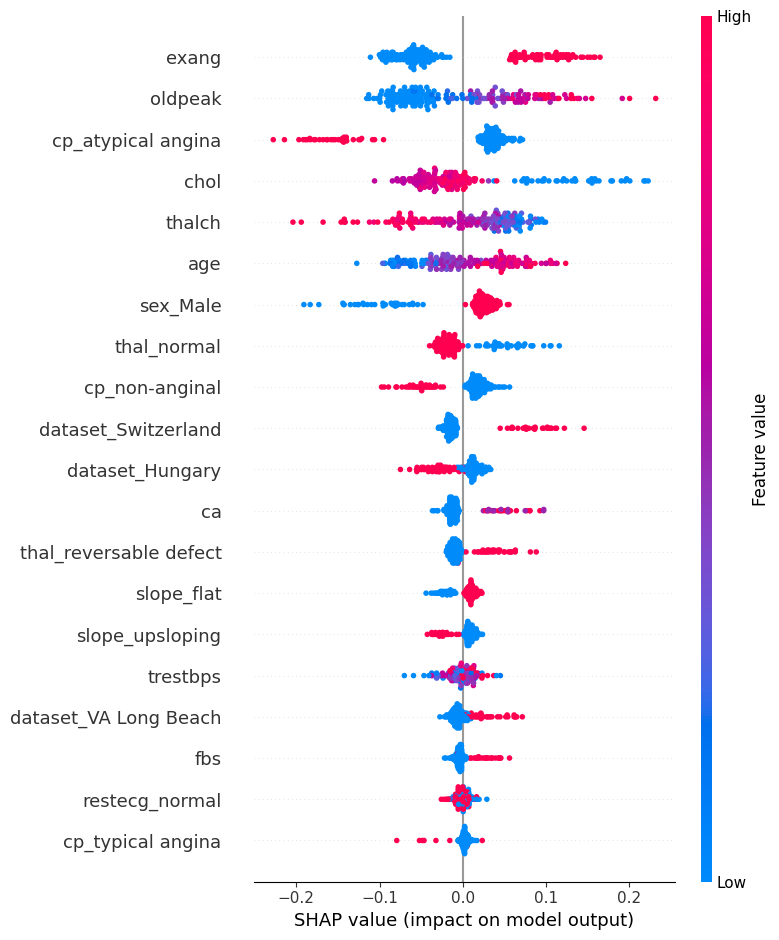

In [13]:
# ============================================
# STEP 13: SHAP Summary Plot
# ============================================

import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

print("="*60)
print("SHAP SUMMARY PLOT")
print("="*60)

# Generate summary plot
shap.summary_plot(shap_values[:, :, 1], X_test)

SHAP FEATURE IMPORTANCE


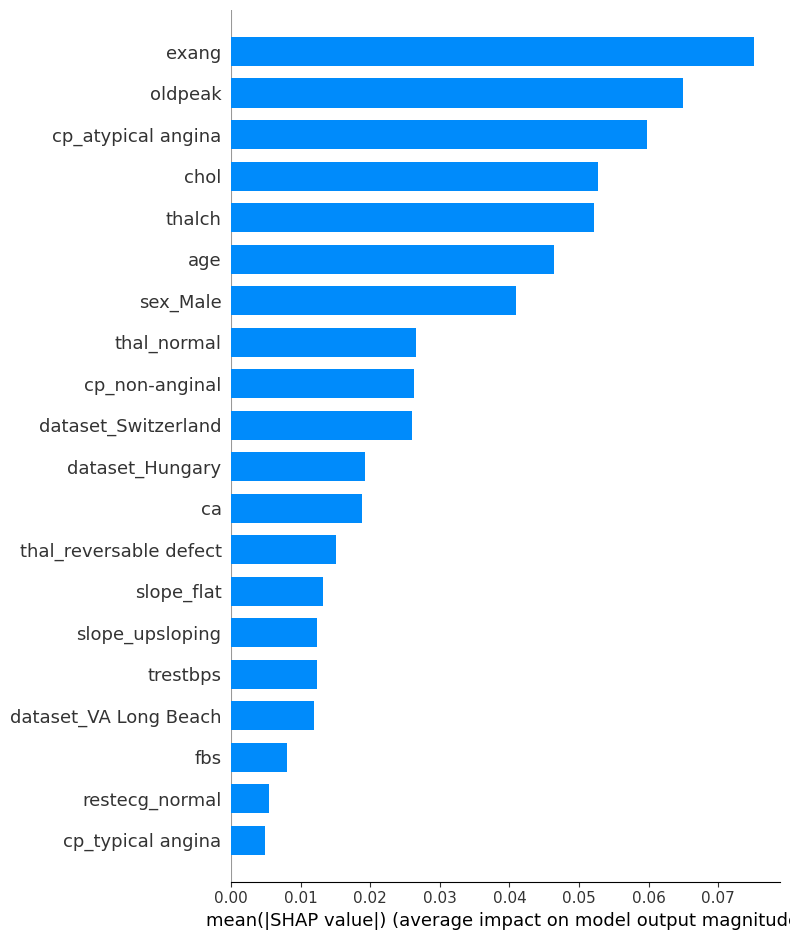

In [14]:
# ============================================
# STEP 14: SHAP Feature Importance (Bar Plot)
# ============================================

print("="*60)
print("SHAP FEATURE IMPORTANCE")
print("="*60)

shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    plot_type="bar"
)

In [15]:
# ============================================
# STEP 15: Install LIME
# ============================================

!pip install lime -q

print("LIME installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
LIME installed successfully!


In [16]:
# ============================================
# STEP 16: Generate LIME Explanation
# ============================================

from lime.lime_tabular import LimeTabularExplainer

# Create LIME explainer
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=["No Heart Disease", "Heart Disease"],
    mode="classification"
)

# Explain the first test instance
explanation = explainer.explain_instance(
    X_test.iloc[0].values,
    model.predict_proba,
    num_features=10
)

print("="*60)
print("LIME EXPLANATION")
print("="*60)

# Display explanation
explanation.show_in_notebook(show_table=True)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


LIME EXPLANATION


# SHAP vs. LIME Comparison

| Aspect | SHAP | LIME |
|---------|------|------|
| Explainability | Global + Local | Local |
| Model Support | Model-specific & Model-agnostic | Model-agnostic |
| Interpretation | Based on Shapley Values | Local Linear Approximation |
| Feature Importance | Global ranking available | Instance-specific |
| Computational Cost | Higher | Lower |
| Consistency | High | Moderate |
| Best Use Case | Understanding overall model behavior | Explaining individual predictions |

### Observations

- SHAP provides both global and local explanations of model predictions.
- LIME focuses on explaining one prediction at a time.
- SHAP offers more consistent feature importance across the dataset.
- LIME is computationally faster and easier to interpret for individual patients.
- Together, SHAP and LIME improve transparency and trust in AI-based healthcare predictions.

# Research Findings

The Random Forest classifier achieved an accuracy of **84.24%** on the Heart Disease UCI dataset.

SHAP analysis identified **exercise-induced angina (exang), oldpeak, cholesterol (chol), maximum heart rate (thalach), and age** as the most influential predictors.

LIME successfully explained individual patient predictions by identifying the local contribution of each feature.

The combination of SHAP and LIME significantly improved model interpretability while maintaining strong predictive performance.

The study demonstrates that Explainable AI techniques enhance transparency and support trustworthy clinical decision-making.

# Quantitative Evaluation

| Evaluation Metric | Value |
|-------------------|-------|
| Dataset | Heart Disease UCI |
| Records | 920 |
| Features (after encoding) | 21 |
| Algorithm | Random Forest |
| Accuracy | 84.24% |
| ROC-AUC Score | 0.8363 |
| Explainability Methods | SHAP, LIME |
| Model Type | Binary Classification |

# Research Methodology

1. Selected the Heart Disease UCI dataset containing 920 patient records.

2. Performed exploratory data analysis using Python and Pandas.

3. Preprocessed the dataset by handling missing values and encoding categorical variables.

4. Split the dataset into training (80%) and testing (20%) sets.

5. Trained a Random Forest classifier for heart disease prediction.

6. Evaluated the model using Accuracy, Confusion Matrix, Classification Report, and ROC-AUC Score.

7. Applied SHAP to provide both global and local model explanations.

8. Applied LIME to explain individual patient predictions.

9. Compared SHAP and LIME based on explainability, interpretability, and computational characteristics.

10. Documented findings, limitations, and future research directions.

# Limitations

- The study used only the Heart Disease UCI dataset containing 920 records.
- Only the Random Forest algorithm was evaluated.
- Missing values were handled using simple imputation techniques.
- The study focused on binary heart disease prediction.
- External clinical validation was beyond the scope of this work.

# Future Work

Future research should compare additional machine learning algorithms including XGBoost, LightGBM, CatBoost, Support Vector Machines, and Deep Learning models.

Further studies should investigate Explainable AI techniques including Integrated Gradients, Anchors, Counterfactual Explanations, and Partial Dependence Plots.

Future work may also evaluate larger clinical datasets, electronic health records, and real-time healthcare applications.

The integration of Explainable AI with Large Language Models and AI-powered clinical decision support systems represents a promising direction for future intelligent healthcare research.

# Conclusion

This project demonstrates the effectiveness of Explainable Artificial Intelligence in improving transparency for machine learning-based heart disease prediction.

The Random Forest classifier achieved an accuracy of 84.24%, indicating strong predictive performance on the Heart Disease UCI dataset.

SHAP successfully provided global feature importance and individual prediction explanations, while LIME effectively explained local prediction behavior for individual patients.

The combination of predictive modeling and Explainable AI techniques enhances trust, interpretability, and accountability, making AI systems more suitable for healthcare decision support.

These findings highlight the importance of integrating explainability into clinical AI applications to support transparent and reliable medical diagnosis.